# KPIs

## Librerias

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

## Carga de datos

In [27]:
data_path = "../../Data/260126/Silver_BANK_marketing_260126.csv"
df = pd.read_csv(data_path, sep=",", encoding="utf-8")


In [28]:
df.head()

,id,age,job,marital,education,credit_default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,0,2343,1,0,low_quality,5,may,1042,1,-1,0,unknown,1
1,2,59,admin.,married,secondary,0,2343,1,0,low_quality,5,may,1042,1,-1,0,unknown,1
2,3,56,admin.,married,secondary,0,45,0,0,low_quality,5,may,1467,1,-1,0,unknown,1
3,4,41,technician,married,secondary,0,1270,1,0,low_quality,5,may,1389,1,-1,0,unknown,1
4,5,55,services,married,secondary,0,2476,1,0,low_quality,5,may,579,1,-1,0,unknown,1


In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10988 entries, 0 to 10987
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              10988 non-null  int64 
 1   age             10988 non-null  int64 
 2   job             10988 non-null  object
 3   marital         10988 non-null  object
 4   education       10988 non-null  object
 5   credit_default  10988 non-null  int64 
 6   balance         10988 non-null  int64 
 7   housing         10988 non-null  int64 
 8   loan            10988 non-null  int64 
 9   contact         10988 non-null  object
 10  day             10988 non-null  int64 
 11  month           10988 non-null  object
 12  duration        10988 non-null  int64 
 13  campaign        10988 non-null  int64 
 14  pdays           10988 non-null  int64 
 15  previous        10988 non-null  int64 
 16  poutcome        10988 non-null  object
 17  deposit         10988 non-null  int64 
dtypes: int

## Cálculo de KPIs

### 1. Porcentaje de Conversión a Depósito

In [18]:
# total de clientes contactados
total_clients = df.shape[0]

# número de clientes que suscribieron depósito
total_deposits = df['deposit'].sum()

# porcentaje de conversión
conversion = (total_deposits / total_clients) * 100

conversion

np.float64(48.143429195485986)

In [19]:
#distribución de conversiones por mes
conversion_month = (
    df
    .groupby("month")
    .agg(
        total_clients=("deposit", "count"),
        conversions=("deposit", "sum"),
        cr=("deposit", lambda x: (x.mean() * 100).round(2))
    )
    .reset_index()
)

conversion_month

,month,total_clients,conversions,cr
0,apr,912,577,63.27
1,aug,1495,688,46.02
2,dec,110,100,90.91
3,feb,764,441,57.72
4,jan,338,142,42.01
5,jul,1487,627,42.17
6,jun,1209,546,45.16
7,mar,275,248,90.18
8,may,2766,926,33.48
9,nov,926,403,43.52


In [20]:
cr_distribution = conversion_month["cr"].agg(
    min_cr="min",
    q1_cr=lambda x: x.quantile(0.25),
    median_cr="median",
    q3_cr=lambda x: x.quantile(0.75),
    max_cr="max"
)

cr_distribution_pct = (cr_distribution).round(2)


In [200]:
# estadísticas de la distribución de CR para definir valores normales 
summary_table = (
    cr_distribution_pct
    .rename({
        "min_cr": "Min CR (%)",
        "q1_cr": "Q1 CR (%)",
        "median_cr": "Median CR (%)",
        "q3_cr": "Q3 CR (%)",
        "max_cr": "Max CR (%)"
    })
    .to_frame(name="Value")
)

summary_table

,Value
Min CR (%),33.48
Q1 CR (%),43.18
Median CR (%),51.87
Q3 CR (%),83.40
Max CR (%),90.91


### 2. Promedio de Duración de Llamadas de Suscriptores

In [21]:
# filtrar solo los clientes que suscribieron
subscribers = df[df['deposit'] == 1]

# suma de duración de llamadas
sum_duration = subscribers['duration'].sum()

# número de suscriptores
num_subscribers = subscribers.shape[0]

# promedio
avg_duration = sum_duration / num_subscribers

# conversión a minutos y segundos
minutes = int(avg_duration // 60)
seconds = int(avg_duration % 60)

avg_duration_f = (f"{minutes} min {seconds} s")

In [22]:
avg_duration_f


'8 min 57 s'

### 3. Porcentaje de Llamadas a Teléfono o Móvil

In [202]:
# total de contactos durante la campaña 
total_contacts = df['campaign'].sum()

# llamadas realizadas por teléfono o móvil
total_calls = df.loc[df['contact'].isin(['telephone', 'cellular']), 'campaign'].sum()

# porcentaje
pct_calls = (total_calls / total_contacts) * 100

pct_calls

np.float64(77.06895298990047)

### 4. Promedio de Contactos previos de Suscriptores

In [203]:
# filtrar solo suscriptores
subscribers = df[df['deposit'] == 1]

# promedio de contactos previos
avg_prev_contacts = subscribers['previous'].mean()

avg_prev_contacts

np.float64(1.170132325141777)

### 5. Mes con Mayor Tasa de Conversión

In [204]:
"""
El tamaño mínimo de la muestra es de aproximadamente 384 clientes
para garantizar que la estimación de CR tenga un error de no más de ±5 puntos porcentuales
con un nivel de confianza del 95 %.

Según Cochran’s Sample Size Formula.
"""

MIN_N = 384

#encuentra el CR máximo entre los meses con volumen suficiente
max_cr_valid = (
    conversion_month
    .loc[conversion_month["total_clients"] >= MIN_N, "cr"]
    .max()
)

In [205]:
def highlight_best_month(row):
    if (row["total_clients"] >= MIN_N) and (row["cr"] == max_cr_valid):
        return ["background-color: #6fdc8c; color: black; font-weight: 600;"] * len(row)
    else:
        return [""] * len(row)


In [213]:
(
    conversion_month
    .style
    .apply(highlight_best_month, axis=1)
    .format({"cr": "{:.2f}%"})
)

,month,total_clients,conversions,cr
4,jan,338,142,42.01%
3,feb,764,441,57.72%
7,mar,275,248,90.18%
0,apr,912,577,63.27%
8,may,2766,926,33.48%
6,jun,1209,546,45.16%
5,jul,1487,627,42.17%
1,aug,1495,688,46.02%
11,sep,316,269,85.13%
10,oct,390,323,82.82%


In [207]:
valid = conversion_month[conversion_month["total_clients"] >= MIN_N].copy()

top_row = valid.loc[valid["cr"].idxmax()]
top_month = top_row["month"]

top_month 

'oct'

In [208]:
orden_meses = ["jan", "feb", "mar", "apr", "may", "jun",
               "jul", "aug", "sep", "oct", "nov", "dec"]

In [209]:

conversion_month["month"] = pd.Categorical(conversion_month["month"], categories=orden_meses, ordered=True)
conversion_month = conversion_month.sort_values("month")

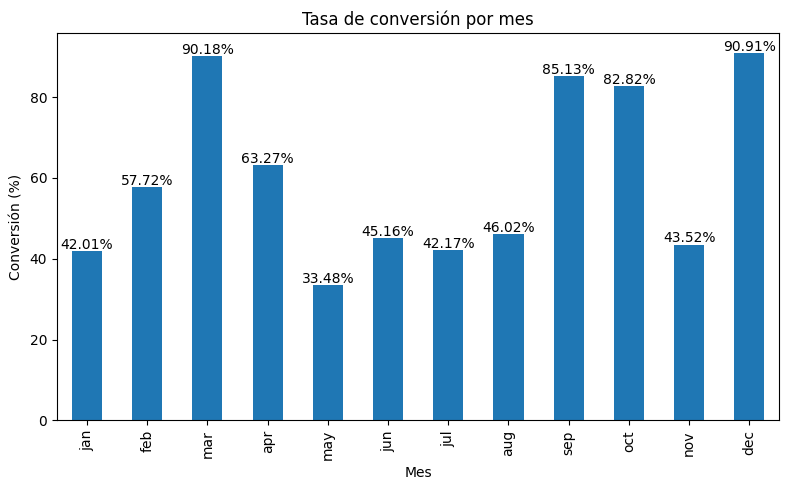

In [210]:

ax = conversion_month.plot(x="month", y="cr", kind="bar", figsize=(8, 5), legend=False)

plt.title("Tasa de conversión por mes")
plt.xlabel("Mes")
plt.ylabel("Conversión (%)")

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

ax.set_ylim(0, conversion_month["cr"].max() + 5)

plt.tight_layout()
plt.show()


### Dataframe de KPIs

In [211]:
kpi_data = {
    "KPI": [
        "Tasa de conversión global (%)",
        "Duración media llamadas (suscriptores)",
        "Porcentaje llamadas teléfono/móvil (%)",
        "Promedio contactos previos (suscriptores)",
        "Mes con mayor conversión",
        "Tasa de conversión del mejor mes (%)"
    ],
    "Valor": [
        round(conversion, 2),
        avg_duration_f,
        round(pct_calls, 2),
        round(avg_prev_contacts, 2),
        top_month,
        round(max_cr_valid, 2)
    ]
}

In [212]:

kpi_df = pd.DataFrame(kpi_data, index=range(1, len(kpi_data["KPI"]) + 1))
kpi_df

,KPI,Valor
1,Tasa de conversión global (%),48.14
2,Duración media llamadas (suscriptores),8 min 57 s
3,Porcentaje llamadas teléfono/móvil (%),77.07
4,Promedio contactos previos (suscriptores),1.17
5,Mes con mayor conversión,oct
6,Tasa de conversión del mejor mes (%),82.82


### Comparacion con datos previos 

#### Outcome KPI
1. **Tasa de conversión global**

Semana 1 49.7%  
Semana 2 48.14% 

mean = 48.92

El valor ha disminuido un 1,56% respecto a la primera semana.

El desempeño habitual del CR se sitúa entre el primer y tercer cuartil (43.18%–83.40%) y tiene valor 48.14, lo que define un rango operativo estable del indicador.

#### Control / Stability metrics
1. **Duración media llamadas (suscriptores)**

Semana 1 8:57 
Semana 2 8:57

sin cambios 

2. **% llamadas teléfono / móvil**

Semana 1 77.26% 
Semana 2 77.07% 

El valor ha disminuido un 0,19% respecto a la primera semana.

3. **Promedio contactos previos (suscriptores)**

Semana 1 1.17
Semana 2 1.17 

sin cambios 

#### Descriptive / Exploratory
1. **Mes con mayor conversión + Tasa de conversión del mejor mes (%)**	 
Semana 1 December 91.74
Semana 2 December 90.91 -> October 82.82 

El valor ha disminuido un 0,83% respecto a la primera semana.

Pero un análisis en profundidad reveló que octubre es el mes más efectivo en términos de campaña y factor de confianza, con una alta tasa de conversión y un alto número de clientes. Y muestra 82.82% de CR por lo tanto, no se excede el nivel de la distribución normal del indicador, sino que se encuentra en su límite superior.


### Insights

1. La disminución observada en CR está dentro de la variabilidad normal del indicador y no indica una degradación en la efectividad de la campaña. 

2. La ausencia de cambios en las métricas operativas indica estabilidad del proceso y ausencia de cambios estructurales en el comportamiento del cliente. 

3. Octubre representa un período de rendimiento de campaña constantemente alto, en contraste con diciembre, donde el alto CR se explica por la cantidad limitada de datos. 


Los KPI se utilizan correctamente como una herramienta de seguimiento, no como un desencadenante de decisiones de emergencia. 

Octubre puede considerarse un punto de referencia para evaluar la eficacia de las campañas con un volumen de datos comparable. 

La CR se apoya en:
- Duración moderada de las llamadas
- Número reducido de contactos
- Asignación correcta de canales

Esto indica un modelo de interacción con el cliente eficaz.

#### Propuestas

1. En esta etapa, es aconsejable utilizar el rango de normalidad CR en lugar de un valor objetivo fijo. 

2. Se recomienda utilizar octubre como período de referencia para analizar los factores de efectividad de la campaña (canal, frecuencia de contacto, duración). 

3. Para evaluar el desempeño mensual, sólo se deben considerar los períodos con suficiente volumen de observación para evitar la distorsión de los indicadores.